In [64]:
try:
  import datasets, evaluate, accelerate
  import gradio as gr
except ModuleNotFoundError:
  !pip install -U datasets evaluate accelerate gradio # -U stands for "upgrade" so we'll get the latest version by default
  import datasets, evaluate, accelerate
  import gradio as gr

import random

import numpy as np
import pandas as pd

import torch
import transformers

print(f"Using transformers version: {transformers.__version__}")
print(f"Using datasets version: {datasets.__version__}")
print(f"Using torch version: {torch.__version__}")

Using transformers version: 4.57.3
Using datasets version: 4.4.2
Using torch version: 2.9.0+cu126


In [65]:
#Dataset
from datasets import load_dataset

dataset = load_dataset("mrdbourke/learn_hf_food_not_food_image_captions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [66]:
#What features
dataset.column_names
dataset['train'][0]

{'text': 'Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
 'label': 'food'}

###Inspect Random Samples


In [67]:
import random
random_indexs=random.sample(range(len(dataset['train'])), 5)
random_samples=dataset['train'][random_indexs]
random_samples

for text, label in zip(random_samples['text'], random_samples['label']):
  print(f"Text: {text}| Label: {label}")


Text: Set of spatulas kept in a holder| Label: not_food
Text: Mouthwatering paneer tikka masala, featuring juicy paneer in a rich tomato-based sauce, garnished with fresh coriander leaves.| Label: food
Text: Pair of reading glasses left open on a book| Label: not_food
Text: Set of board games stacked on a shelf| Label: not_food
Text: Two handfuls of bananas in a fruit bowl with grapes on the side, the fruit bowl is blue| Label: food


In [68]:
#Unique Dataset labels
dataset['train'].unique('label')

['food', 'not_food']

In [69]:
# of each label
from collections import Counter
Counter(dataset['train']['label'])

Counter({'food': 125, 'not_food': 125})

In [70]:
#Pandas
food_not_food_df=pd.DataFrame(dataset['train'])
food_not_food_df.sample(6)


,text,label
142,A slice of pizza with a generous amount of shr...,food
6,Pair of reading glasses left open on a book,not_food
97,Telescope positioned on a balcony,not_food
60,A close-up of a family playing a board game wi...,not_food
112,Rich and spicy lamb rogan josh with yogurt gar...,food
181,"A steaming bowl of fiery chicken curry, infuse...",food


In [71]:
food_not_food_df['label'].value_counts()

,count
label,
food,125
not_food,125


###Preparing Data


In [72]:
id2label={0:"not_food", 1:"food"}
label2id={"not_food":0, "food":1}

In [73]:
id2label={idx: label for idx, label in enumerate(dataset['train'].unique('label')[::-1])}
label2id={label:idx for idx, label in id2label.items()}
print(id2label, label2id)

{0: 'not_food', 1: 'food'} {'not_food': 0, 'food': 1}


In [74]:
#labels into 0 or 1
def map_labels_to_number(example):
  example['label']=label2id[example['label']]
  return example


In [75]:
dataset=dataset['train'].map(map_labels_to_number)
dataset[:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [76]:
#train and test split
dataset=dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [77]:
#tokenizing
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert/distilbert-base-uncased", use_fast=True)

In [78]:
tokenizer("ping pong")
tokenizer.vocab["water"]

2300

In [79]:
#preprocessing function
def tokenize_text(example):
  return tokenizer(example['text'], padding=True, truncation=True)

In [80]:
test={'text':"bing chilling", "label":1}
tokenize_text(test)

{'input_ids': [101, 17620, 27017, 102], 'attention_mask': [1, 1, 1, 1]}

In [81]:
tokenized_dataset=dataset.map(function=tokenize_text, batched=True, batch_size=1000)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 50
    })
})

In [82]:
tokenizer.all_special_tokens


['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']

In [83]:
tokenizer.all_special_ids


[100, 102, 0, 101, 103]

In [84]:
train_tokenized_sample=tokenized_dataset['train'][0]
test_tokenized_sample=tokenized_dataset['test'][0]

for key in train_tokenized_sample.keys():
  print(f"Info: Key:{key}")
  print(f"Train sample:{train_tokenized_sample[key]}")
  print(f"Test sample: {test_tokenized_sample[key]}")
  print()


Info: Key:text
Train sample:Set of headphones placed on a desk
Test sample: A slice of pepperoni pizza with a layer of melted cheese

Info: Key:label
Train sample:0
Test sample: 1

Info: Key:input_ids
Train sample:[101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Info: Key:attention_mask
Train sample:[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



In [85]:
import numpy as np
from typing import Tuple
import evaluate

accuracy_metric=evaluate.load("accuracy")

def compute_accuracy(predictions_and_labels: Tuple[np.array, np.array]):
  predictions, labels=predictions_and_labels
  if len(predictions.shape)>=2:
    predictions=np.argmax(predictions, axis=1)
  return accuracy_metric.compute(predictions=predictions, references=labels)

In [86]:
from transformers import AutoModelForSequenceClassification

model=AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id
    )

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [87]:
#Count parameters
def count_params(model):
  trainable_parameters=sum(param.numel() for param in model.parameters() if param.requires_grad)
  total_parameters=sum(param.numel() for param in model.parameters())
  return {"trainable_parameters": trainable_parameters, "total_parameters": total_parameters}
count_params(model)

{'trainable_parameters': 66955010, 'total_parameters': 66955010}

In [88]:
from pathlib import Path

models_dir=Path('models')
models_dir.mkdir(exist_ok=True)

model_save_name="learn_hf_food_not_food_text_classifier-distilibert-base-uncased"
model_save_dir=Path(models_dir, model_save_name)
model_save_dir

PosixPath('models/learn_hf_food_not_food_text_classifier-distilibert-base-uncased')

In [89]:
from transformers import TrainingArguments
print(model_save_dir)

BATCH_SIZE=32
training_args=TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    use_cpu=False,
    seed=42,
    load_best_model_at_end=True,
    logging_strategy="epoch",
    report_to="none",
    hub_private_repo=False

)

models/learn_hf_food_not_food_text_classifier-distilibert-base-uncased


In [90]:
from transformers import Trainer
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    processing_class=tokenizer,
    compute_metrics=compute_accuracy
)

In [91]:
results=trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.443000,0.134152,0.980000
2,0.052100,0.011799,1.000000
3,0.005300,0.027990,0.980000
4,0.002000,0.005633,1.000000
5,0.001200,0.001494,1.000000
6,0.000900,0.000924,1.000000
7,0.000700,0.000758,1.000000
8,0.000600,0.000691,1.000000
9,0.000600,0.000662,1.000000
10,0.000600,0.000653,1.000000


In [92]:
#Inspect training metrics
for key,value in results.metrics.items():
  print(f"{key}:{value}")

train_runtime:16.9091
train_samples_per_second:118.28
train_steps_per_second:4.14
total_flos:18110777160000.0
train_loss:0.05068276909046939
epoch:10.0


In [93]:
#save model
print(model_save_dir)
trainer.save_model(output_dir=model_save_dir)

models/learn_hf_food_not_food_text_classifier-distilibert-base-uncased


###Inspect Training Metrics


In [94]:
#getting history
trainer_history_all=trainer.state.log_history
trainer_history_metrics=trainer_history_all[:-1]

trainer_history_training_time=trainer_history_all[-1]

In [95]:
import pprint

trainer_history_training_set=[]
trainer_history_eval_set=[]

for item in trainer_history_metrics:
  item_keys=list(item.keys())
  if any ('eval' in item for item in item_keys):
    trainer_history_eval_set.append(item)
  else:
    trainer_history_training_set.append(item)

print("training set")
pprint.pprint(trainer_history_training_set[:2])

print("eval set")
pprint.pprint(trainer_history_eval_set[:2])



training set
[{'epoch': 1.0,
  'grad_norm': 1.889009952545166,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.443,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.17813551425933838,
  'learning_rate': 8.142857142857143e-05,
  'loss': 0.0521,
  'step': 14}]
eval set
[{'epoch': 1.0,
  'eval_accuracy': 0.98,
  'eval_loss': 0.13415178656578064,
  'eval_runtime': 0.032,
  'eval_samples_per_second': 1561.578,
  'eval_steps_per_second': 62.463,
  'step': 7},
 {'epoch': 2.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.011798996478319168,
  'eval_runtime': 0.0283,
  'eval_samples_per_second': 1767.228,
  'eval_steps_per_second': 70.689,
  'step': 14}]


In [96]:
#loss curves
trainer_history_train_df=pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df=pd.DataFrame(trainer_history_eval_set)

trainer_history_train_df.head()


,loss,grad_norm,learning_rate,epoch,step
0,0.4430,1.889010,0.000091,1.0,7
1,0.0521,0.178136,0.000081,2.0,14
2,0.0053,0.036683,0.000071,3.0,21
3,0.0020,0.031592,0.000061,4.0,28
4,0.0012,0.014284,0.000051,5.0,35


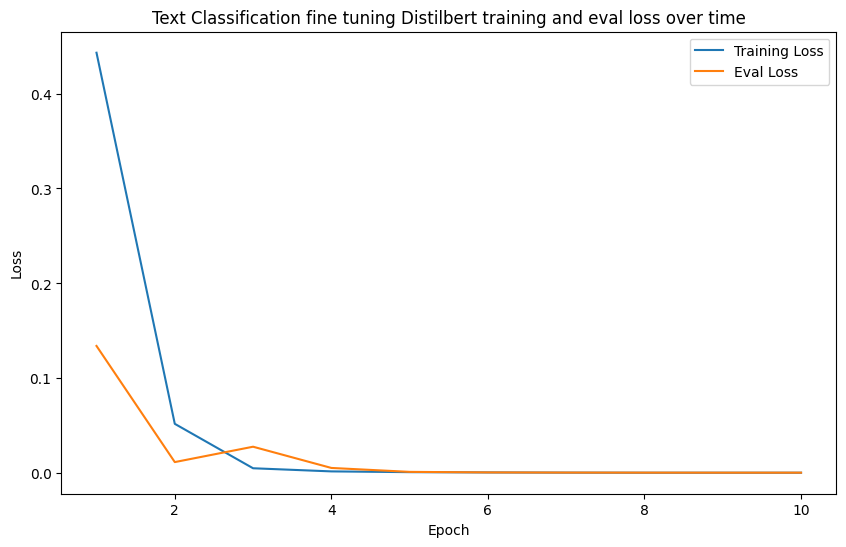

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(trainer_history_train_df['epoch'],trainer_history_train_df["loss"], label="Training Loss")

plt.plot(trainer_history_eval_df['epoch'],trainer_history_eval_df["eval_loss"], label="Eval Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text Classification fine tuning Distilbert training and eval loss over time")
plt.legend()
plt.show()

In [98]:
#push to hugging face
model_upload_url=trainer.push_to_hub(commit_message="Uploading food text classifier model")
print("Sucess"+model_upload_url)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...uncased/model.safetensors:   5%|4         | 13.3MB /  268MB            

  ...uncased/training_args.bin:   2%|1         |   102B / 5.91kB            

Sucesshttps://huggingface.co/TheAryanAnode/learn_hf_food_not_food_text_classifier-distilibert-base-uncased/tree/main/


In [99]:
#make predictions
predictions_all=trainer.predict(tokenized_dataset['test'])
prediction_values=predictions_all.predictions
prediction_metric=predictions_all.metrics

prediction_metric


{'test_loss': 0.00065287557663396,
 'test_accuracy': 1.0,
 'test_runtime': 0.0319,
 'test_samples_per_second': 1565.062,
 'test_steps_per_second': 62.602}

###Predicted Probabilities


In [100]:
import torch
from sklearn.metrics import accuracy_score

pred_probs=torch.softmax(torch.tensor(prediction_values), dim=1)

pred_labels=torch.argmax(pred_probs, dim=1)

true_labels=tokenized_dataset['test']['label']

test_accuracy=accuracy_score(y_true=true_labels, y_pred=pred_labels)

test_accuracy

1.0

In [101]:
#Check where the model went wrong(in this case it didnt)
test_predictions_df=pd.DataFrame({"text":tokenized_dataset['test']['text'],
                                  "true_label":true_labels,
                                  "pred_label":pred_labels,
                                  "pred_prob":torch.max(pred_probs, dim=1).values
                                  })
test_predictions_df.head()

,text,true_label,pred_label,pred_prob
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.999390
1,Red brick fireplace with a mantel serving as a...,0,0,0.999668
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.999392
3,Set of mugs hanging on a hook,0,0,0.999726
4,Standing floor lamp providing light next to an...,0,0,0.999725


In [102]:
#lowest 10 predictions
test_predictions_df.sort_values("pred_prob", ascending=True).head(10)

,text,true_label,pred_label,pred_prob
43,Set of muffin tins stacked together,0,0,0.992582
17,"Relaxing on the porch, a couple enjoys the com...",0,0,0.999346
40,A bowl of cherries with a sprig of mint for ga...,1,1,0.999374
42,"Boxes of apples, pears, pineapple, manadrins a...",1,1,0.999376
11,A close-up shot of a cheesy pizza slice being ...,1,1,0.999376
26,A fruit platter with a variety of exotic fruit...,1,1,0.999377
14,Two handfuls of bananas in a fruit bowl with g...,1,1,0.999378
34,"Mouthwatering mushroom curry, featuring shiita...",1,1,0.999384
49,Plate of sushi served with pickled ginger and ...,1,1,0.999385
35,Luxurious coconut shrimp curry on a generous p...,1,1,0.999385


###predicting with custom data


In [103]:
local_model_path="/content/models/learn_hf_food_not_food_text_classifier-distilibert-base-uncased"

hugging_face_model_path="TheAryanAnode/learn_hf_food_not_food_text_classifier-distilibert-base-uncased"

In [104]:
def set_device():
  if torch.cuda.is_available:
    device=torch.device("cuda")
  elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device=torch.device("mps")
  else:
    device=torch.device("cpu")
Device=set_device()
print(Device)

None


In [105]:
#Inference with a pipeline
import torch
from transformers import pipeline

BATCH_SIZE=32

food_not_food_classifier=pipeline(task="text-classification",
                                  model=local_model_path, batch_size=BATCH_SIZE,
                                  top_k=1,
                                  )


Device set to use cuda:0


In [106]:
test_custom_sentence="yummy ice cream cake with onions and olives"
food_not_food_classifier(test_custom_sentence)

[[{'label': 'food', 'score': 0.9993883371353149}]]

In [107]:
#use pipeline from hugging face
del food_not_food_classifier

from transformers import pipeline

food_not_food_classifier=pipeline(task="text-classification", model=hugging_face_model_path, top_k=1, batch_size=BATCH_SIZE)

food_not_food_classifier(test_custom_sentence)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Device set to use cuda:0


[[{'label': 'food', 'score': 0.9993883371353149}]]

In [108]:
#multiple pred same time
sentences = [
    "The startup finally cooked after three years of raw ideas and half-baked plans.",
    "He spoon-fed the algorithm just enough data to stop it from starving.",
    "The deal fell apart once everyone realized the numbers were sugar-coated.",
    "She carved out a niche in the market while everyone else was still chewing on the problem.",
    "The proposal looked meaty, but there was no substance once you bit into it.",
    "They toasted the merger, unaware the company was already burned.",
    "After the audit, the entire plan was put through a grinder.",
    "The policy was designed to keep small players from eating each other alive.",
    "He served the same stale arguments, hoping no one would notice the expiration date.",
    "Once the hype cooled, the project was left on the table untouched."
]


food_not_food_classifier(sentences
                         )

[[{'label': 'food', 'score': 0.9992190599441528}],
 [{'label': 'not_food', 'score': 0.9843645691871643}],
 [{'label': 'food', 'score': 0.9977387189865112}],
 [{'label': 'not_food', 'score': 0.9955097436904907}],
 [{'label': 'food', 'score': 0.9987655878067017}],
 [{'label': 'not_food', 'score': 0.9785526394844055}],
 [{'label': 'not_food', 'score': 0.9984567165374756}],
 [{'label': 'food', 'score': 0.6981179714202881}],
 [{'label': 'not_food', 'score': 0.6212872266769409}],
 [{'label': 'not_food', 'score': 0.996533989906311}]]

In [110]:
#time models across larges sample sizes
import time

sentences_1000=sentences*1000

print(f"Num of sentences {len(sentences_1000)}")

start_time=time.time()
for sentence in sentences_1000:
  food_not_food_classifier(sentence)
end_time_one_at_a_time=time.time()

total=end_time_one_at_a_time-start_time
print(total)


Num of sentences 10000
45.386340618133545


In [112]:
#now in batches

for i in [10, 100, 1000, 10000]:
  sentences_big=sentences*i
  print(len(sentences_big))
  start_time=time.time()
  food_not_food_classifier(sentences_big)
  end_time=time.time()
  total=end_time-start_time
  print(total)


100
0.05562615394592285
1000
0.4787557125091553
10000
4.556541442871094
100000
46.00034952163696


###predictions with pytorch

In [114]:
from transformers import AutoTokenizer

model_path="TheAryanAnode/learn_hf_food_not_food_text_classifier-distilibert-base-uncased"

sample_food_text="photo of a plate of eggs, toast, beans, and cheese"

tokenizer=AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_path)
inputs=tokenizer(sample_food_text, return_tensors="pt")


In [115]:
from transformers import AutoModelForSequenceClassification

model=AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_path)

In [117]:
import torch
model.eval()
with torch.inference_mode():
  outputs=model(**inputs)

predicted_class_id=outputs.logits.argmax().item()
predicted_class_id

1

In [120]:
prediction_probability=torch.softmax(outputs.logits, dim=1).max().item()
prediction_probability

0.9993830919265747

###Gradio interface


In [127]:
#create a inference function

from typing import Dict

def food_not_food_classifier(text:str) -> Dict[str,float]:
  food_not_food_classifier_pipeline=pipeline(task="text-classification", model=local_model_path, batch_size=32, device="cuda" if torch.cuda.is_available() else "cpu", top_k=None)

  outputs=food_not_food_classifier_pipeline(text)[0]
  output_dict={}
  for item in outputs:
    output_dict[item['label']]=item['score']
  return output_dict
food_not_food_classifier(text="bing chilling")

Device set to use cuda


{'not_food': 0.9993109703063965, 'food': 0.0006890498916618526}

In [129]:
import gradio as gr

demo=gr.Interface(fn=food_not_food_classifier, inputs='text', outputs=gr.Label(num_top_classes=2), title="Food Not Food Classifier", description="A text classifier to determine if a sentence is about food or not", examples=[["Ice cream cake with onions"], ["A cat jumping from cloud to cloud"]])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://893942c0a1d0761415.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
